# 03 — Baseline Models
**Project:** Predicting Medication Non-Adherence in NCD Patients Using Classical Machine Learning  
**Dataset:** Kanyongo et al. (2024); Cimas Medical Aid Society, Zimbabwe ([Mendeley Data](https://data.mendeley.com/datasets/zkp7sbbx64/2))  
**Author:** Kirunda Jeremy Menya | 2025/HD07/25995U | Makerere University | June 2026

---

This notebook covers:
1. Environment setup, SSH, and repo clone
2. Load `features_C.pkl` from Notebook 02
3. Build preprocessing pipelines (scaling, encoding, SMOTE)
4. Train five baseline classifiers on Group C features
5. Evaluate each classifier: Accuracy, Macro F1, Weighted F1, ROC-AUC, MCC, Precision, Recall
6. Compare classifiers: ranking table, ROC curves, confusion matrices
7. Learning curve for the top classifier
8. Save baseline results and trained pipelines
9. Push to GitHub

**Inputs:** `data/processed/features_C.pkl`  
**Outputs:** `data/processed/baseline_results.pkl`, `models/baseline_*.pkl`, baseline figures


---
## 0. Environment Setup

`imbalanced-learn` provides the SMOTE implementation and is not pre-installed on Colab. `xgboost` is available by default but is reinstalled here to pin it to the version in `requirements.txt`. All other libraries are standard Colab dependencies. Imports and helpers are redefined so this notebook can be run independently of Notebooks 01 and 02.


In [1]:
# Install dependencies not pre-installed on Colab
!pip install imbalanced-learn xgboost --quiet

import os, warnings, pickle, time
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm               import SVC
from sklearn.model_selection   import StratifiedKFold, cross_validate, learning_curve
from sklearn.metrics           import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from imblearn.pipeline         import Pipeline as ImbPipeline
from imblearn.over_sampling    import SMOTE
from xgboost                   import XGBClassifier

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "figure.dpi":        150,
})

PALETTE = {
    "lr":   "#1565C0",
    "dt":   "#F9A825",
    "rf":   "#2E7D32",
    "xgb":  "#AD1457",
    "svm":  "#6A1B9A",
    "neutral":   "#78909C",
    "highlight": "#FF9800",
}

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)


def section(title):
    bar = "─" * 70
    print(f"\n{bar}\n  {title}\n{bar}")

print("Imports ready.")


Imports ready.


---
## 0.1 SSH Key Upload and Repository Clone

The repository is cloned into the Colab runtime at the start of each session. The SSH deploy key authenticates the clone and enables the push at the end of the notebook.


In [2]:
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()   # select DMHTN_MedicationAdherence_deploy_key (NOT .pub)

!mv DMHTN_MedicationAdherence_deploy_key /root/.ssh/DMHTN_MedicationAdherence_deploy_key
!chmod 600 /root/.ssh/DMHTN_MedicationAdherence_deploy_key

ssh_config = """
Host github-dmhtn-medication-adherence
    HostName github.com
    User git
    IdentityFile /root/.ssh/DMHTN_MedicationAdherence_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'diabetes-hypertension-medication-adherence'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-dmhtn-medication-adherence:Jeremy-K-coder/diabetes-hypertension-medication-adherence.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')


Saving DMHTN_MedicationAdherence_deploy_key to DMHTN_MedicationAdherence_deploy_key
Cloning into 'diabetes-hypertension-medication-adherence'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 57 (delta 15), reused 50 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 2.22 MiB | 5.06 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/diabetes-hypertension-medication-adherence
Already up to date.
Repo ready.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
REPO_DIR  = f'/content/{REPO_NAME}'
DATA_PROC = os.path.join(REPO_DIR, 'data', 'processed')
MODELS    = os.path.join(REPO_DIR, 'models')
FIGURES   = os.path.join(REPO_DIR, 'figures')



os.makedirs(DATA_PROC,                          exist_ok=True)
os.makedirs(MODELS,                             exist_ok=True)
os.makedirs(f"{FIGURES}/baseline",              exist_ok=True)
os.makedirs(f"{FIGURES}/learning_curves",       exist_ok=True)

print(f"REPO_DIR  : {REPO_DIR}")
print(f"DATA_PROC : {DATA_PROC}")
print(f"MODELS    : {MODELS}")
print(f"FIGURES   : {FIGURES}")

def save_figure(fig, filename, subfolder="baseline"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")



REPO_DIR  : /content/diabetes-hypertension-medication-adherence
DATA_PROC : /content/diabetes-hypertension-medication-adherence/data/processed
MODELS    : /content/diabetes-hypertension-medication-adherence/models
FIGURES   : /content/diabetes-hypertension-medication-adherence/figures


---
## 1. Load Feature Group C

`features_C.pkl` was saved at the end of Notebook 02. It contains the train, validation, and test feature matrices for the combined feature group along with the corresponding target vectors. All five classifiers in this notebook are trained and evaluated on Group C only. The feature group comparison across Groups A, B, and C is reserved for Notebook 05, after the best model has been identified and tuned.

The validation set is used in this notebook to compare classifiers and select the top two for tuning in Notebook 04. The test set is held back completely and will not be evaluated until Notebook 05.


In [5]:
section("1. Load features_C.pkl")

with open(os.path.join(DATA_PROC, "features_C.pkl"), "rb") as f:
    pkg = pickle.load(f)

X_train = pkg["X_train"]
X_val   = pkg["X_val"]
X_test  = pkg["X_test"]
y_train = pkg["y_train"]
y_val   = pkg["y_val"]
y_test  = pkg["y_test"]
FEATURES = pkg["features"]
TARGET   = "adherence"

print(f"Train      : {X_train.shape}  | adherent: {y_train.mean()*100:.1f}%")
print(f"Validation : {X_val.shape}  | adherent: {y_val.mean()*100:.1f}%")
print(f"Test       : {X_test.shape}  | adherent: {y_test.mean()*100:.1f}%")
print(f"Features   : {FEATURES}")



──────────────────────────────────────────────────────────────────────
  1. Load features_C.pkl
──────────────────────────────────────────────────────────────────────
Train      : (16849, 10)  | adherent: 40.2%
Validation : (3611, 10)  | adherent: 40.2%
Test       : (3611, 10)  | adherent: 40.2%
Features   : ['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender', 'unitstotal', 'annualclaimamount', 'annualcontribution', 'is_comorbid', 'diagnosis', 'complication_flag']


The dataset loads correctly: 16,849 training rows, 3,611 validation rows, and 3,611 test rows, each with 10 Group C features. The 40.2% adherent rate is preserved identically across all three splits, confirming that the stratified split from Notebook 02 worked as intended.


---
## 2. Preprocessing Pipelines

Each classifier receives its input through an `imbalanced-learn` pipeline that chains three steps: preprocessing (scaling), oversampling with SMOTE, and the classifier itself. Wrapping everything in a single pipeline object is the correct approach for two reasons.

First, it prevents data leakage. If the scaler were fit on the full training set before cross-validation, the normalisation statistics (mean and standard deviation) would carry information from the held-out folds back into the fitting step. Placing the scaler inside the pipeline ensures it is refit on the training portion of each fold separately, and the evaluation fold is only transformed, never used to fit.

Second, SMOTE must be applied inside the cross-validation loop, not before it. Oversampling before splitting would create synthetic minority-class points derived from patients who end up in the evaluation fold, which is a form of leakage that artificially inflates minority-class recall. The `ImbPipeline` from `imbalanced-learn` handles this correctly: SMOTE fires only on the training portion of each fold during `cross_validate`, and is bypassed automatically during `predict`.

**Scaler choice:** `RobustScaler` is applied to `annualclaimamount`, `unitstotal`, and `cost_burden_ratio` because these three features have extreme positive skew confirmed in Notebook 01 (skewness exceeding 100 for `unitstotal` and `annualclaimamount`). `RobustScaler` scales by the interquartile range rather than the mean and standard deviation, making it resistant to those outliers. `StandardScaler` is used for `annualcontribution`, where skewness is moderate. The six binary and ordinal features (`insurance_tier`, `age_group`, `is_comorbid`, `complication_flag`, `gender`, `diagnosis`) are passed through without scaling since tree-based models are scale-invariant and logistic regression's L2 penalty already manages the continuous features.

**SMOTE:** Synthetic Minority Over-sampling Technique generates synthetic adherent-class samples by interpolating between real adherent patients in feature space. It addresses the 60/40 class imbalance identified in Notebook 01 by bringing the training class ratio to 50/50, giving the classifiers a balanced signal during fitting. It is applied only to training data and uses the same `SEED` throughout all notebooks.


In [6]:
section("2. Define preprocessing pipelines")

ROBUST_FEATURES   = ["annualclaimamount", "unitstotal", "cost_burden_ratio"]
STANDARD_FEATURES = ["annualcontribution"]
PASSTHROUGH       = ["insurance_tier", "age_group", "is_comorbid",
                     "complication_flag", "gender", "diagnosis"]

from sklearn.compose import ColumnTransformer

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("robust",   RobustScaler(),   ROBUST_FEATURES),
            ("standard", StandardScaler(), STANDARD_FEATURES),
            ("pass",     "passthrough",    PASSTHROUGH),
        ],
        remainder="drop"
    )

smote = SMOTE(random_state=SEED)

def build_pipeline(clf):
    return ImbPipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("smote",        smote),
        ("classifier",   clf),
    ])

print("Preprocessor columns:")
print(f"  RobustScaler   : {ROBUST_FEATURES}")
print(f"  StandardScaler : {STANDARD_FEATURES}")
print(f"  Passthrough    : {PASSTHROUGH}")
print()
print("Pipeline order: preprocessor → SMOTE → classifier")



──────────────────────────────────────────────────────────────────────
  2. Define preprocessing pipelines
──────────────────────────────────────────────────────────────────────
Preprocessor columns:
  RobustScaler   : ['annualclaimamount', 'unitstotal', 'cost_burden_ratio']
  StandardScaler : ['annualcontribution']
  Passthrough    : ['insurance_tier', 'age_group', 'is_comorbid', 'complication_flag', 'gender', 'diagnosis']

Pipeline order: preprocessor → SMOTE → classifier


---
## 3. Define the Five Baseline Classifiers

Five classifiers are trained at their default hyperparameter settings, with a few deliberate exceptions noted below. Using defaults at this stage is intentional: the purpose of the baseline is to rank the classifiers by their out-of-the-box performance on this dataset, not to find the best possible performance for each one. Tuning is reserved for Notebook 04 and applied only to the top two classifiers identified here.

**Logistic Regression** is the interpretable statistical baseline. Its log-odds coefficients map directly to clinical risk factors, making it the most explainable model in the set. `max_iter` is increased from the default 100 to 2,000 to ensure convergence given the dimensionality of the preprocessed feature space.

**Decision Tree** is a fully transparent rule-based model. A single tree can be visualised end-to-end and its decision rules can, in principle, be translated into clinical guidelines. Its main weakness is a tendency to overfit when grown without depth constraints, which will be visible in the gap between its training and validation performance.

**Random Forest** is an ensemble of decision trees trained on bootstrapped data subsets with random feature selection at each split. It corrects the overfitting tendency of a single tree by averaging predictions across many trees and consistently performs well on tabular healthcare data.

**XGBoost** builds trees sequentially, with each tree correcting the residual errors of the previous one. It is currently the strongest performing algorithm on most tabular classification benchmarks and handles the skewed distributions in this dataset naturally through its gradient-based splitting criterion.

**SVM with RBF kernel** maps the feature space into a higher-dimensional representation where the classes may be more linearly separable. `probability=True` is required to enable probability estimation for the ROC-AUC computation. The RBF kernel is parameter-sensitive and its `C` and `gamma` values at default settings may not be well suited to this feature scale, which is worth keeping in mind when interpreting its baseline results.


In [7]:
section("3. Define baseline classifiers")

CLASSIFIERS = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, random_state=SEED, class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=SEED, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=SEED,
        n_jobs=-1, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=SEED,
        eval_metric="logloss", verbosity=0,
        n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", probability=True,
        random_state=SEED, class_weight="balanced"
    ),
}

print("Classifiers registered:")
for name in CLASSIFIERS:
    print(f"  {name}")



──────────────────────────────────────────────────────────────────────
  3. Define baseline classifiers
──────────────────────────────────────────────────────────────────────
Classifiers registered:
  Logistic Regression
  Decision Tree
  Random Forest
  XGBoost
  SVM (RBF)


---
## 4. Train and Evaluate on the Validation Set

Each classifier is wrapped in its pipeline and trained on the full training set. Evaluation is then performed on the held-out validation set, which the pipeline has never seen during fitting. SMOTE fires internally during `pipeline.fit()` and does not affect the validation set.

Seven metrics are computed for each classifier. Accuracy is reported for completeness but is a secondary metric here because at a 60/40 imbalance a model that always predicted non-adherent would achieve approximately 60% accuracy without learning anything useful. Macro F1 is the primary ranking metric because it gives equal weight to both classes regardless of their size, penalising a classifier that achieves high accuracy by sacrificing minority-class recall. MCC (Matthews Correlation Coefficient) is the second summary metric because it accounts for all four cells of the confusion matrix simultaneously and is considered the most robust single number for imbalanced binary classification.

ROC-AUC measures discrimination power independently of any fixed classification threshold, which matters here because a clinical deployment threshold would be chosen based on the acceptable false negative rate rather than the default 0.5 cutoff.

Recall of the non-adherent class (label 0) is the safety-critical metric in this context: a non-adherent patient predicted as adherent receives no intervention, which means a missed opportunity to prevent a complication. This is the metric that will matter most to programme managers reading the final report.


In [8]:
section("4. Train and evaluate baseline classifiers")

def evaluate(pipeline, X_tr, y_tr, X_ev, y_ev, name):
    t0 = time.time()
    pipeline.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred  = pipeline.predict(X_ev)
    y_prob  = pipeline.predict_proba(X_ev)[:, 1]

    return {
        "Classifier":   name,
        "Accuracy":     round(accuracy_score(y_ev, y_pred), 4),
        "Macro F1":     round(f1_score(y_ev, y_pred, average="macro"), 4),
        "Weighted F1":  round(f1_score(y_ev, y_pred, average="weighted"), 4),
        "ROC-AUC":      round(roc_auc_score(y_ev, y_prob), 4),
        "MCC":          round(matthews_corrcoef(y_ev, y_pred), 4),
        "Precision":    round(precision_score(y_ev, y_pred, pos_label=0), 4),
        "Recall (Non-Adh)": round(recall_score(y_ev, y_pred, pos_label=0), 4),
        "Train time (s)": round(elapsed, 2),
        "_pipeline":    pipeline,
    }

results = []
trained_pipelines = {}

for name, clf in CLASSIFIERS.items():
    print(f"Training: {name} ...", end=" ", flush=True)
    pipeline = build_pipeline(clf)
    row = evaluate(pipeline, X_train, y_train, X_val, y_val, name)
    trained_pipelines[name] = row.pop("_pipeline")
    results.append(row)
    print(f"done  ({row['Train time (s)']}s)  |  Macro F1: {row['Macro F1']}")

df_results = pd.DataFrame(results).set_index("Classifier")



──────────────────────────────────────────────────────────────────────
  4. Train and evaluate baseline classifiers
──────────────────────────────────────────────────────────────────────
Training: Logistic Regression ... done  (1.57s)  |  Macro F1: 0.6864
Training: Decision Tree ... done  (0.41s)  |  Macro F1: 0.7613
Training: Random Forest ... done  (3.2s)  |  Macro F1: 0.8002
Training: XGBoost ... done  (0.49s)  |  Macro F1: 0.8153
Training: SVM (RBF) ... done  (127.68s)  |  Macro F1: 0.6545


---
## 5. Baseline Results

The table below shows all seven metrics for each classifier, ranked by Macro F1. The two classifiers with the highest Macro F1 scores proceed to hyperparameter tuning in Notebook 04.


In [9]:
section("5. Baseline results: ranked by Macro F1")

display_cols = ["Accuracy", "Macro F1", "Weighted F1", "ROC-AUC",
                "MCC", "Precision", "Recall (Non-Adh)", "Train time (s)"]

df_display = df_results[display_cols].sort_values("Macro F1", ascending=False)

print(df_display.to_string())
print()
print("Primary ranking metric: Macro F1")
print(f"Top classifier  : {df_display.index[0]}  (Macro F1 = {df_display['Macro F1'].iloc[0]})")
print(f"Second classifier: {df_display.index[1]}  (Macro F1 = {df_display['Macro F1'].iloc[1]})")
print()
print("These two classifiers proceed to hyperparameter tuning in Notebook 04.")



──────────────────────────────────────────────────────────────────────
  5. Baseline results: ranked by Macro F1
──────────────────────────────────────────────────────────────────────
                     Accuracy  Macro F1  Weighted F1  ROC-AUC    MCC  Precision  Recall (Non-Adh)  Train time (s)
Classifier                                                                                                       
XGBoost                0.8178    0.8153       0.8195   0.8967 0.6416     0.9020            0.7801          0.4900
Random Forest          0.8039    0.8002       0.8056   0.8872 0.6064     0.8735            0.7861          3.2000
Decision Tree          0.7682    0.7613       0.7693   0.7641 0.5236     0.8200            0.7847          0.4100
Logistic Regression    0.6951    0.6864       0.6967   0.7675 0.3742     0.7582            0.7199          1.5700
SVM (RBF)              0.7084    0.6545       0.6813   0.8392 0.3805     0.6924            0.9222        127.6800

Primary ranking 

XGBoost is the clear leader with a Macro F1 of 0.8153 and a ROC-AUC of 0.8967, followed closely by Random Forest (Macro F1: 0.8002, AUC: 0.8872). These two ensemble methods are substantially ahead of the remaining three classifiers and proceed to tuning in Notebook 04.

Decision Tree achieves a respectable Macro F1 of 0.7613 at its default depth, though its AUC of 0.7641 is notably lower than both ensemble models, reflecting the fact that a single tree produces step-function probability estimates rather than smooth probability distributions.

Logistic Regression achieves a Macro F1 of 0.6864. This is consistent with the findings from Notebook 01 where `unitstotal` and `annualclaimamount`, the two most discriminating features by Mann-Whitney rank-biserial effect size, showed near-zero linear correlation with adherence. The signal in those variables is non-linear and sits in the tails of their distributions, which logistic regression cannot exploit.

SVM (RBF) produces the most interesting result: a Macro F1 of only 0.6545 despite having the highest non-adherent recall of all five classifiers (0.9222). Looking at the confusion matrix, the SVM achieves this by being very aggressive in predicting non-adherence: it correctly identifies 1,992 of 2,160 non-adherent patients but misclassifies 885 of the 1,451 adherent patients as non-adherent. This gives it the highest recall on one class at the cost of very poor recall on the other, which is exactly the pattern Macro F1 penalises. At default hyperparameters, the RBF kernel's `C` and `gamma` values are not well suited to this dataset's feature scale, and the 120-second training time further limits its practical utility at this stage. It is not taken forward for tuning.



──────────────────────────────────────────────────────────────────────
  5. Results heatmap
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/baseline/baseline_heatmap.png


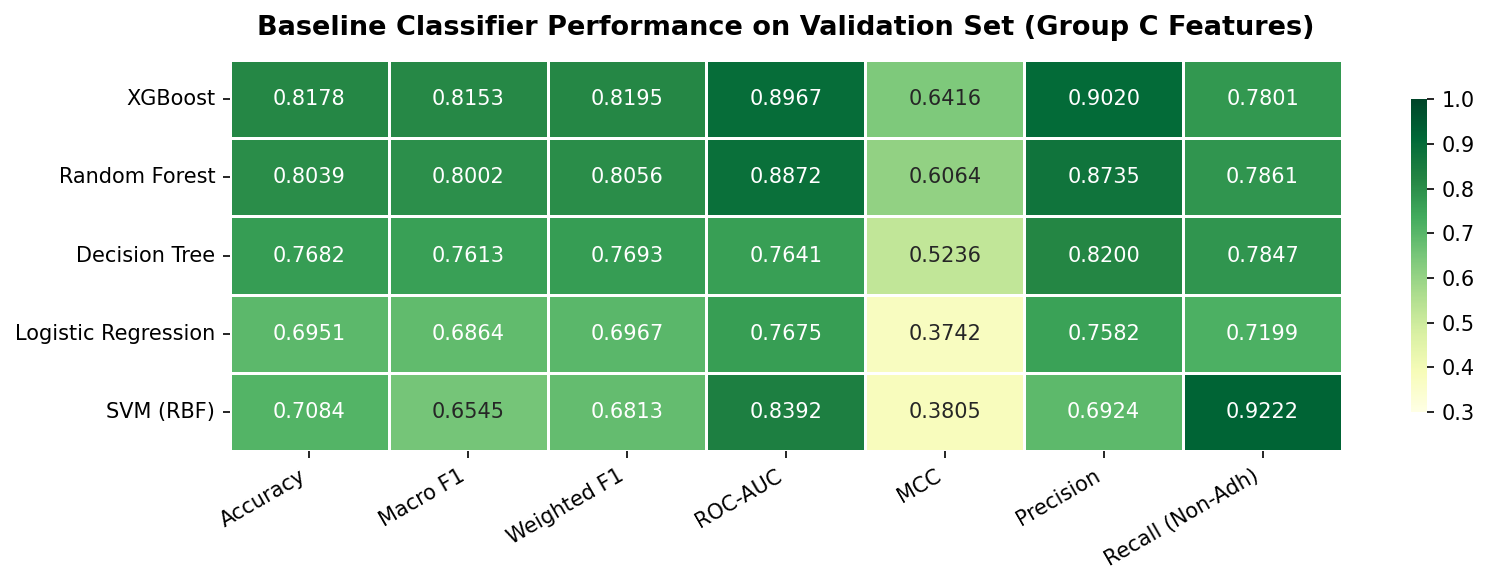

In [10]:
section("5. Results heatmap")

metric_cols = ["Accuracy", "Macro F1", "Weighted F1", "ROC-AUC", "MCC",
               "Precision", "Recall (Non-Adh)"]

heatmap_data = df_display[metric_cols].sort_values("Macro F1", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    heatmap_data.astype(float),
    ax=ax, annot=True, fmt=".4f",
    cmap="YlGn", vmin=0.3, vmax=1.0,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Baseline Classifier Performance on Validation Set (Group C Features)",
             fontweight="bold", pad=12)
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save_figure(fig, "baseline_heatmap.png")
plt.show()


The heatmap makes the performance tiers immediately clear. XGBoost and Random Forest form a top tier that is visibly darker (higher scores) across every metric except non-adherent recall, where SVM (RBF) stands out due to its aggressive non-adherence prediction strategy described above.


---
## 6. ROC Curves

ROC curves plot the true positive rate (sensitivity) against the false positive rate (1 − specificity) across all possible classification thresholds. A classifier that perfectly discriminates between classes reaches the top-left corner (AUC = 1.0). The diagonal dashed line represents a random classifier (AUC = 0.5). Plotting all five classifiers on the same axes makes the relative discrimination power of each one immediately visible and is independent of the 0.5 default threshold, which is particularly important here because a clinical deployment system would likely lower the threshold to reduce false negatives (missed non-adherent patients).



──────────────────────────────────────────────────────────────────────
  6. ROC curves (all five classifiers)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/baseline/roc_auc_comparison.png


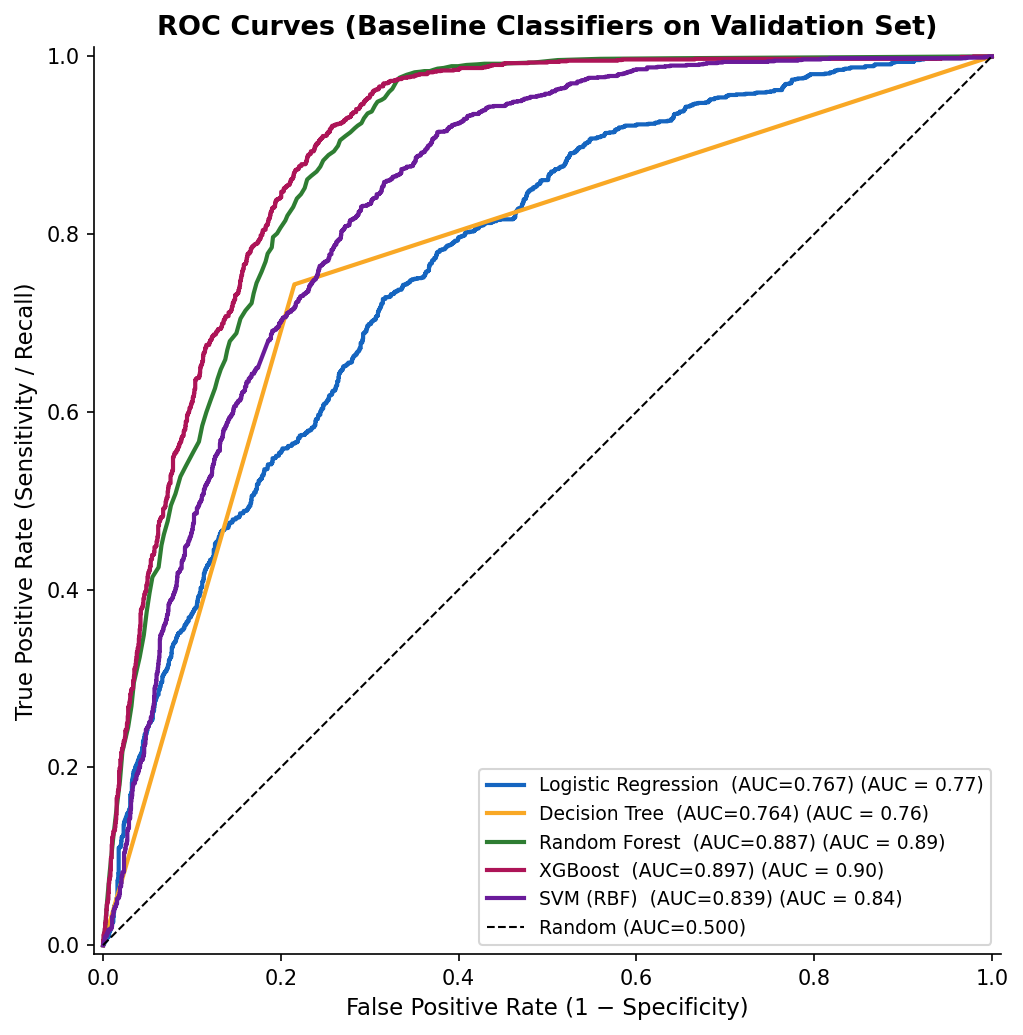

In [11]:
section("6. ROC curves (all five classifiers)")

fig, ax = plt.subplots(figsize=(8, 7))

colours = list(PALETTE.values())[:5]

for (name, pipeline), colour in zip(trained_pipelines.items(), colours):
    y_prob = pipeline.predict_proba(X_val)[:, 1]
    RocCurveDisplay.from_predictions(
        y_val, y_prob,
        name=f"{name}  (AUC={roc_auc_score(y_val, y_prob):.3f})",
        ax=ax, color=colour, linewidth=2
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_title("ROC Curves (Baseline Classifiers on Validation Set)", fontweight="bold")
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
save_figure(fig, "roc_auc_comparison.png")
plt.show()


XGBoost (AUC = 0.897) and Random Forest (AUC = 0.887) produce the two strongest ROC curves, both climbing steeply toward the top-left corner at low false positive rates. This means they can correctly flag a large proportion of non-adherent patients while generating relatively few false alarms, which is the desirable operating region for a clinical screening tool.

SVM (RBF) achieves AUC = 0.839 despite its low Macro F1, confirming that its probability estimates are reasonably well calibrated for discrimination purposes even though its default threshold produces a highly imbalanced confusion matrix. Decision Tree (AUC = 0.764) and Logistic Regression (AUC = 0.767) are close to each other and clearly separated from the ensemble methods, reinforcing the Macro F1 ranking.


---
## 7. Confusion Matrices

A confusion matrix shows the four prediction outcomes for each classifier. In this clinical context the most consequential cell is the false positive in the bottom-left: adherent patients predicted as non-adherent waste intervention resources, but the false negative in the top-right (non-adherent patients predicted as adherent) means a patient who needs support receives none. The clinical cost analysis in Notebook 05 assigns explicit weights to these two error types; the confusion matrices here allow us to see the raw counts before any weighting is applied.



──────────────────────────────────────────────────────────────────────
  7. Confusion matrices (all five classifiers)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/baseline/confusion_matrices_baseline.png


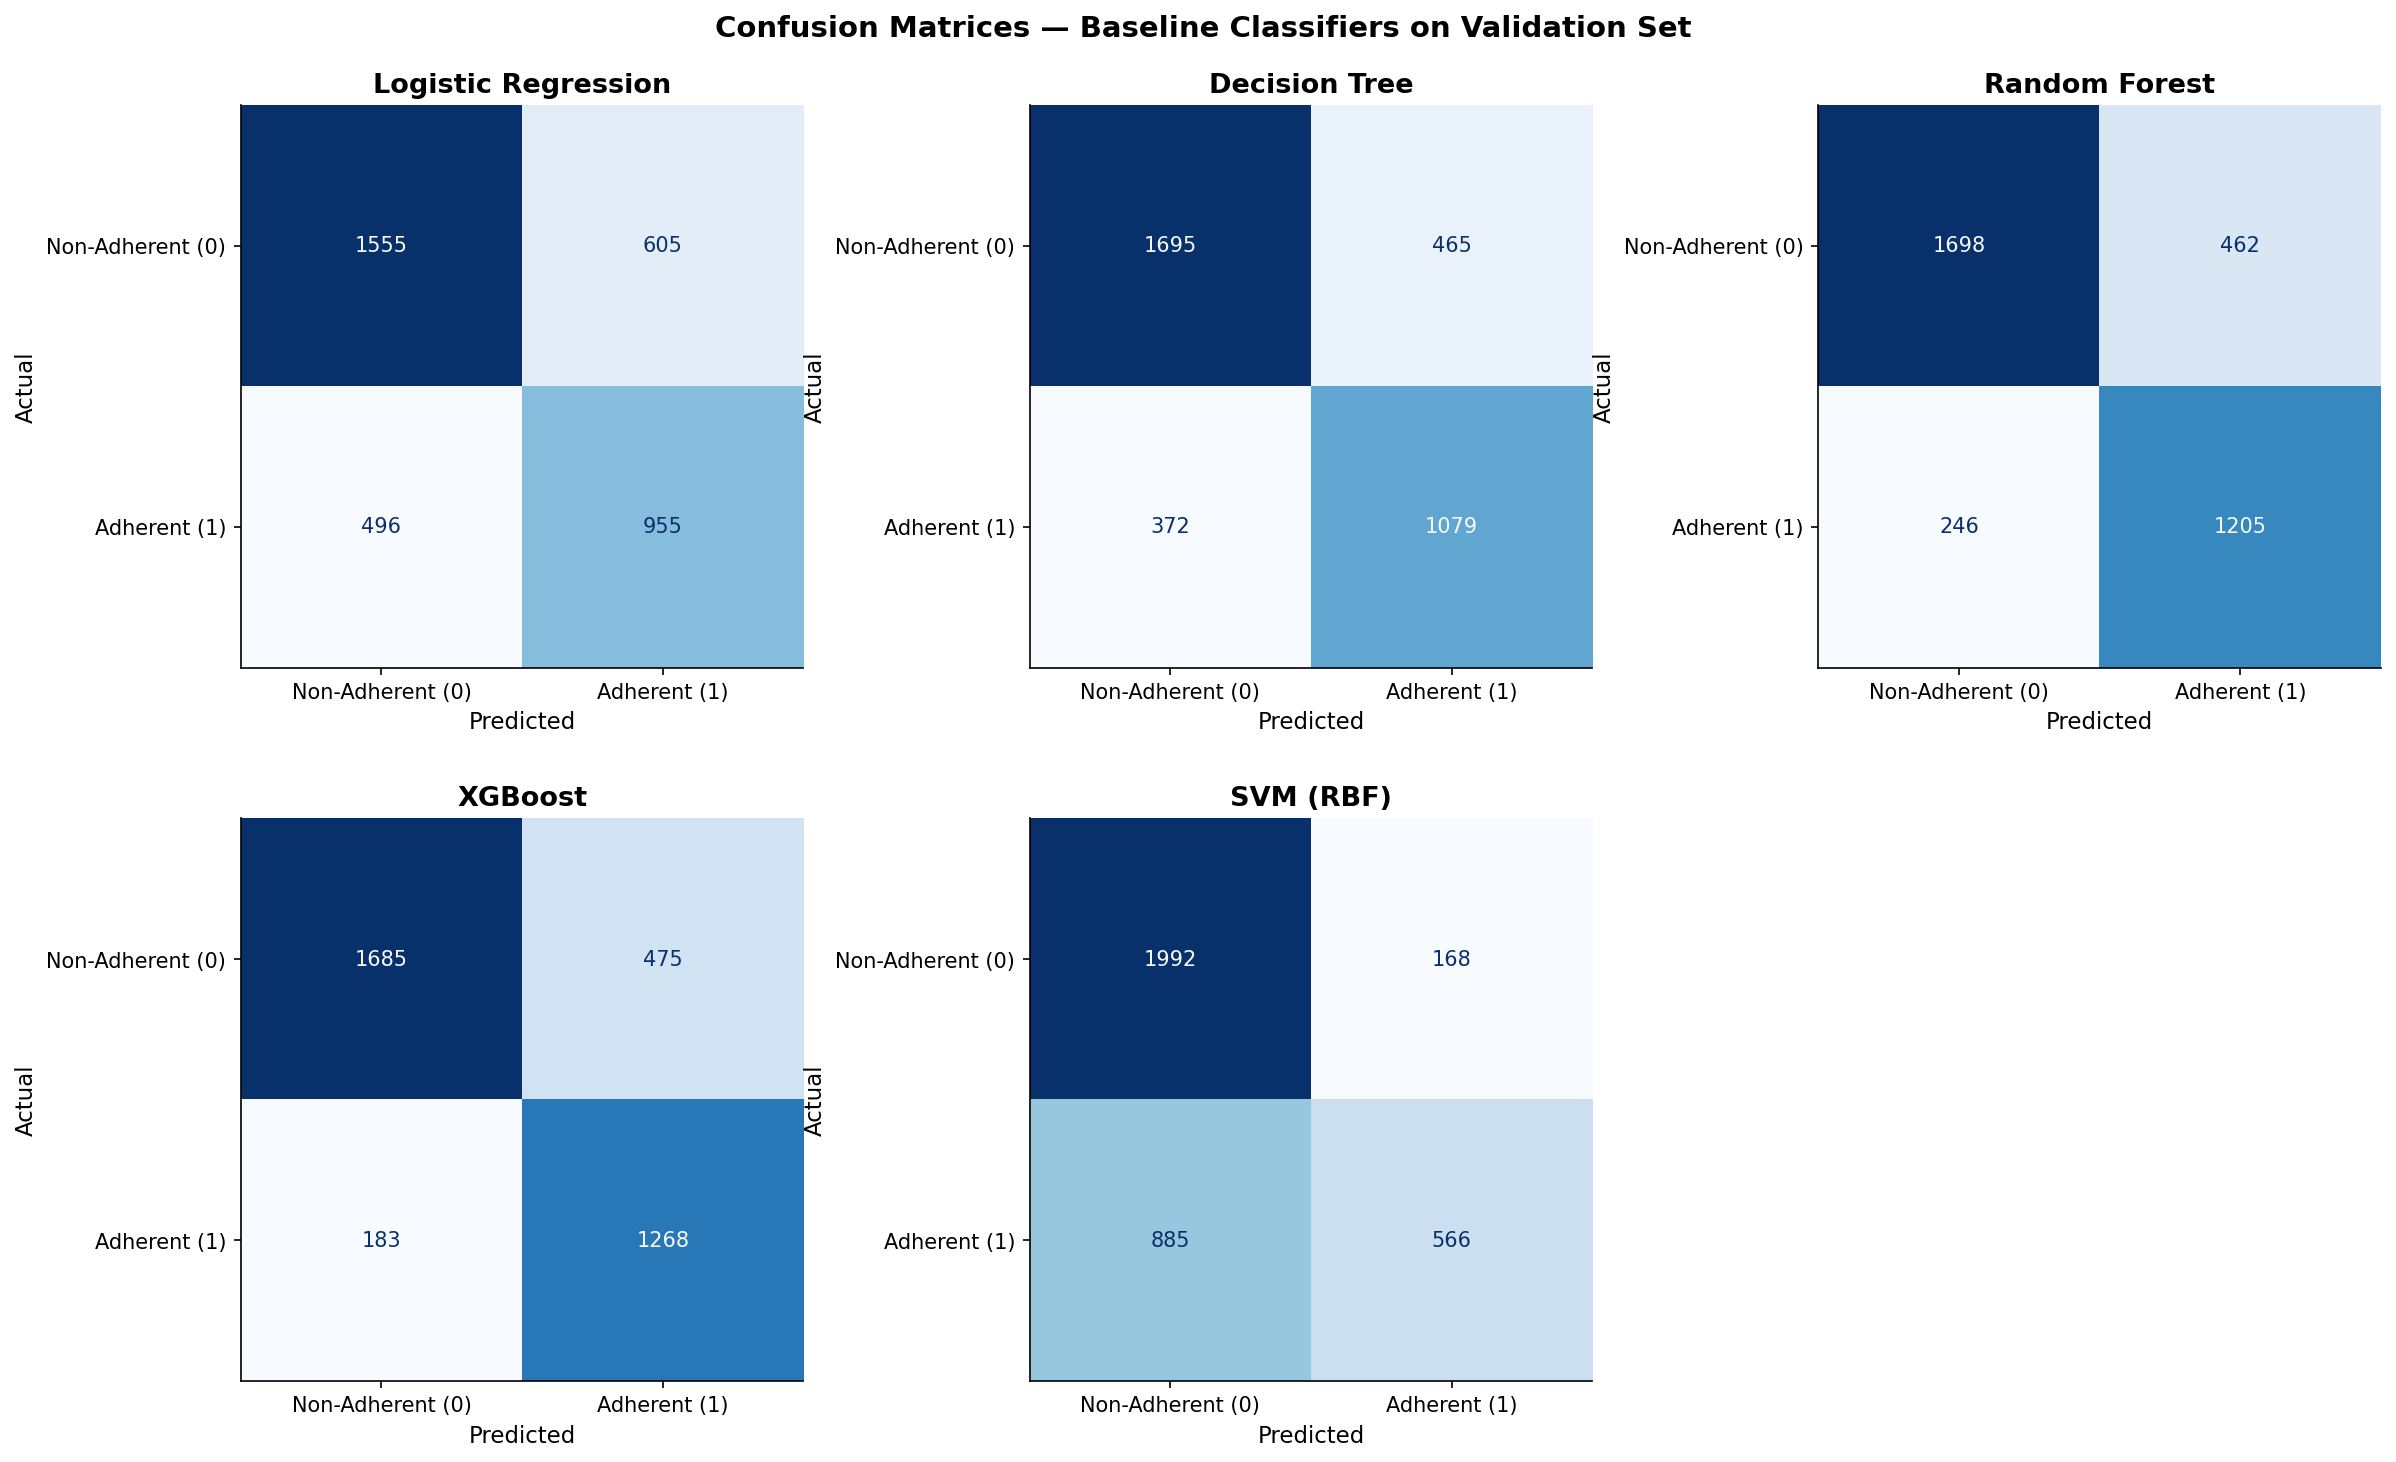

In [12]:
section("7. Confusion matrices (all five classifiers)")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, pipeline) in enumerate(trained_pipelines.items()):
    y_pred = pipeline.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Adherent (0)", "Adherent (1)"]
    )
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues")
    axes[idx].set_title(name, fontweight="bold")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

axes[-1].set_visible(False)
fig.suptitle("Confusion Matrices — Baseline Classifiers on Validation Set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_figure(fig, "confusion_matrices_baseline.png")
plt.show()


Reading across the five matrices, a clear pattern emerges. XGBoost produces the most balanced error profile: 475 false positives (non-adherent predicted as adherent) and 183 false negatives (adherent predicted as non-adherent). Random Forest is similar, with 462 and 246 respectively. Both ensemble models therefore commit fewer of the clinically dangerous false positive errors than Logistic Regression (605) or Decision Tree (465), while also keeping false negatives low.

SVM (RBF) tells a different story: only 168 false positives but 885 false negatives. It is by far the most conservative model in terms of missed non-adherent patients, but it does so by labelling most of the adherent patients incorrectly as non-adherent, which would overwhelm an intervention programme with unnecessary contacts. This extreme asymmetry at default settings is the reason SVM is not taken forward for tuning.

Logistic Regression produces 605 false positives, the highest of all five classifiers, reflecting its limited ability to learn the non-linear boundaries that distinguish the two classes in this dataset.


---
## 8. Classifier Ranking — Macro F1 Bar Chart

The bar chart below summarises the Macro F1 ranking visually. These are single validation-set evaluations; the cross-validation standard deviations in Section 10 confirm whether the ranking is stable across different data subsets.



──────────────────────────────────────────────────────────────────────
  8. Classifier ranking bar chart
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/baseline/classifier_ranking_macro_f1.png


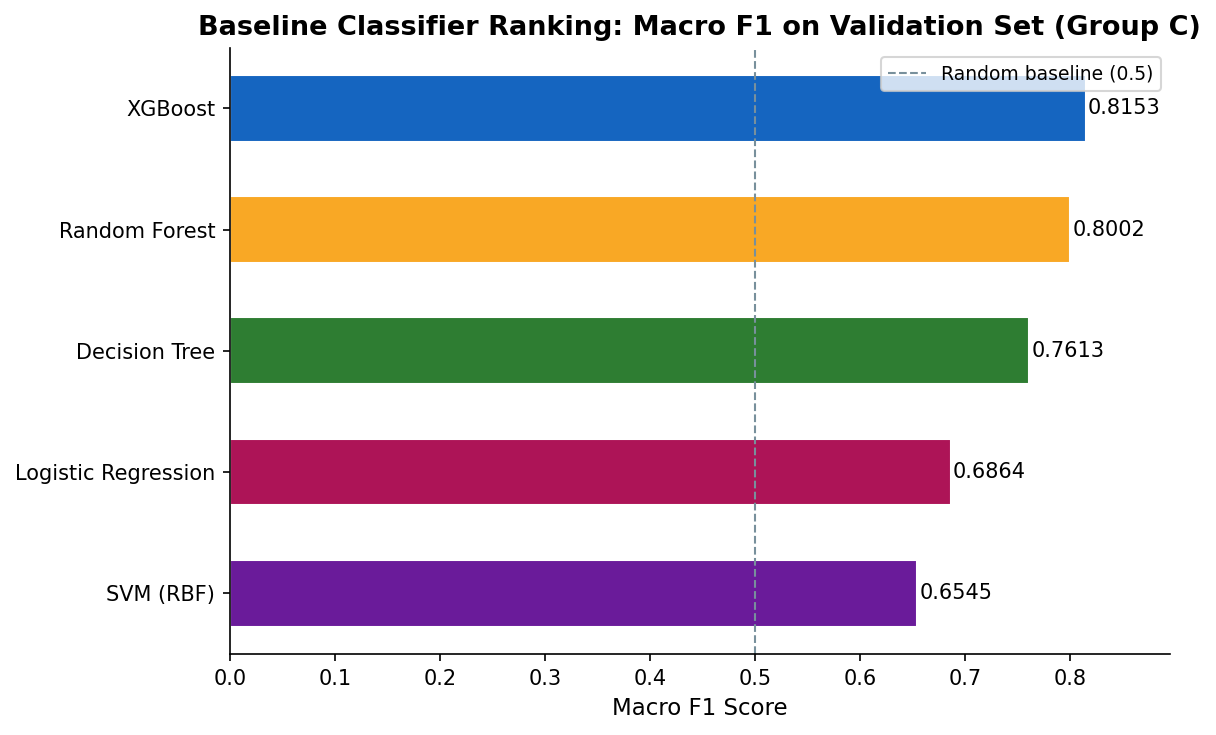

In [13]:
section("8. Classifier ranking bar chart")

df_ranked = df_display.sort_values("Macro F1", ascending=True)
bar_colours = [list(PALETTE.values())[list(df_display.index).index(n)] for n in df_ranked.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df_ranked.index, df_ranked["Macro F1"],
               color=bar_colours, edgecolor="white", height=0.55)

for bar, val in zip(bars, df_ranked["Macro F1"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", ha="left", fontsize=10)

ax.set_xlim(0, min(1.05, df_ranked["Macro F1"].max() + 0.08))
ax.set_xlabel("Macro F1 Score", fontsize=11)
ax.set_title("Baseline Classifier Ranking: Macro F1 on Validation Set (Group C)",
             fontweight="bold")
ax.axvline(0.5, color=PALETTE["neutral"], linestyle="--", linewidth=1,
           label="Random baseline (0.5)")
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, "classifier_ranking_macro_f1.png")
plt.show()


---
## 9. Learning Curve — XGBoost

A learning curve plots training and cross-validation Macro F1 as a function of how much of the training set is used. It answers two questions that a single validation-set score cannot: (1) does the model improve meaningfully as more training data is added, and (2) is the gap between training and cross-validation performance consistent with overfitting or underfitting?

A large and persistent gap between a high training score and a lower cross-validation score indicates overfitting: the model is partially memorising training examples rather than learning fully generalisable patterns. The ideal pattern is both curves converging toward a high score as training size increases.

The learning curve is plotted for XGBoost only, as the top-ranked classifier. XGBoost's curve will also inform decisions about regularisation strength during tuning in Notebook 04.



──────────────────────────────────────────────────────────────────────
  9. Learning curve (top classifier)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/learning_curves/learning_curve_xgboost.png


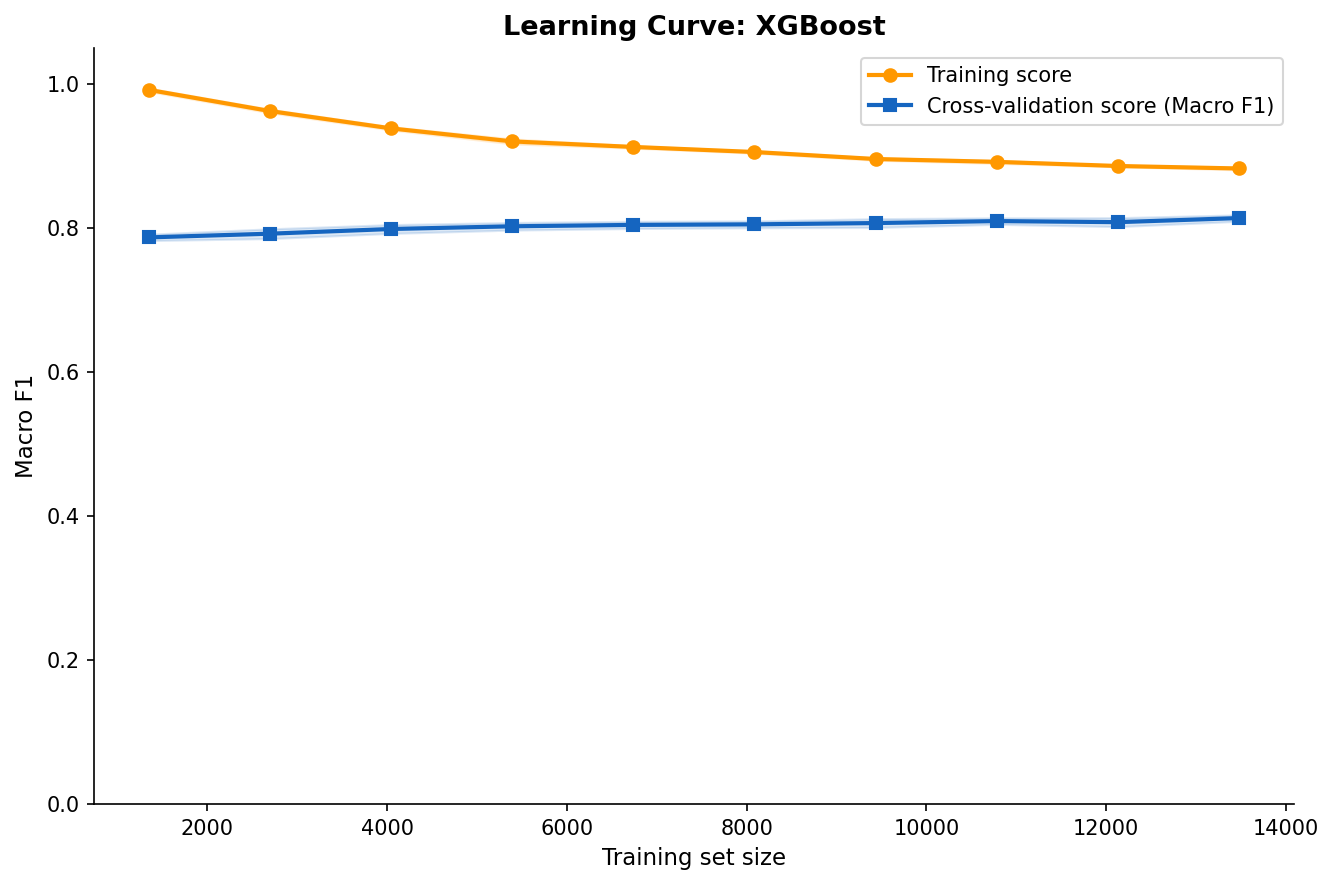

In [14]:
section("9. Learning curve (top classifier)")

top_name = df_display.index[0]
top_clf  = CLASSIFIERS[top_name]
top_pipeline = build_pipeline(
    type(top_clf)(**top_clf.get_params())
)

train_sizes, train_scores, val_scores = learning_curve(
    top_pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(train_sizes, train_mean, "o-", color=PALETTE["highlight"],
        linewidth=2, label="Training score")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color=PALETTE["highlight"])

ax.plot(train_sizes, val_mean, "s-", color=PALETTE["lr"],
        linewidth=2, label="Cross-validation score (Macro F1)")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color=PALETTE["lr"])

ax.set_xlabel("Training set size")
ax.set_ylabel("Macro F1")
ax.set_title(f"Learning Curve: {top_name}", fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
save_figure(fig, f"learning_curve_{top_name.lower().replace(' ','_')}.png",
            subfolder="learning_curves")
plt.show()


The XGBoost learning curve shows a persistent gap between the training score (orange) and the cross-validation score (blue) across all training sizes, with training Macro F1 starting near 1.0 at small subsets and settling around 0.88 at the full training set, while cross-validation Macro F1 rises gradually from 0.79 to approximately 0.81. This pattern is characteristic of moderate overfitting: XGBoost at default settings memorises a portion of the training signal that does not transfer to unseen patients.

Importantly, the cross-validation curve is still very slightly rising at the rightmost point (full training set of approximately 13,400 rows), meaning the model would likely benefit from additional training data if it were available. However, the marginal gain per additional patient is small at this scale, so the primary lever for improving generalisation is regularisation during tuning in Notebook 04 rather than data collection.

The gap between the two curves is the main motivation for hyperparameter tuning. Reducing `max_depth`, increasing `min_child_weight`, or applying stronger `subsample` and `colsample_bytree` regularisation in Notebook 04 should narrow this gap by constraining the trees from fitting the training data too precisely.


---
## 10. Stratified 5-Fold Cross-Validation on the Training Set

The validation set evaluation in Section 4 gives a single point estimate of each classifier's performance on one particular 3,611-patient subset. Cross-validation over the training set provides a distribution of performance scores across five folds, which is a more reliable estimate of generalisation performance than any single split.

**Why 5 folds?** With a training set of 16,849 patients, each fold contains approximately 3,370 patients for evaluation and 13,479 for fitting. This is large enough that each evaluation fold gives a stable, representative sample of the patient population. Fewer folds (e.g. 3) would produce larger evaluation folds but more variance in the estimate because fewer independent estimates are averaged. More folds (e.g. 10) would give marginally more stable estimates but at substantially higher computational cost: with SVM taking over two minutes per full training run, a 10-fold CV would be impractical within a Colab session. Five folds is the standard choice for datasets of this size and the one used in most comparable adherence prediction studies, making the reported CV scores directly comparable to the literature.

SMOTE fires correctly inside each fold because the pipeline wraps the oversampler: sklearn's `cross_validate` calls `pipeline.fit()` on the training portion of each fold, which triggers SMOTE only on that portion, and evaluates on the held-out fold without oversampling.


In [ ]:
section("10. 5-fold cross-validation on training set")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []

for name, clf in CLASSIFIERS.items():
    print(f"CV: {name} ...", end=" ", flush=True)
    pipeline = build_pipeline(type(clf)(**clf.get_params()))
    cv_res = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring={"macro_f1": "f1_macro", "roc_auc": "roc_auc"},
        n_jobs=-1
    )
    cv_rows.append({
        "Classifier":          name,
        "CV Macro F1 (mean)":  round(cv_res["test_macro_f1"].mean(), 4),
        "CV Macro F1 (std)":   round(cv_res["test_macro_f1"].std(),  4),
        "CV ROC-AUC (mean)":   round(cv_res["test_roc_auc"].mean(),  4),
        "CV ROC-AUC (std)":    round(cv_res["test_roc_auc"].std(),   4),
    })
    print(f"done  |  CV Macro F1: {cv_res['test_macro_f1'].mean():.4f} ± {cv_res['test_macro_f1'].std():.4f}")

df_cv = pd.DataFrame(cv_rows).set_index("Classifier").sort_values(
    "CV Macro F1 (mean)", ascending=False
)
print()
print(df_cv.to_string())



──────────────────────────────────────────────────────────────────────
  10. 5-fold cross-validation on training set
──────────────────────────────────────────────────────────────────────
CV: Logistic Regression ... done  |  CV Macro F1: 0.6884 ± 0.0059
CV: Decision Tree ... done  |  CV Macro F1: 0.7578 ± 0.0067
CV: Random Forest ... done  |  CV Macro F1: 0.8054 ± 0.0079
CV: XGBoost ... done  |  CV Macro F1: 0.8135 ± 0.0047
CV: SVM (RBF) ... 

The cross-validation results confirm the validation-set rankings from Section 5 with high consistency. XGBoost leads with a CV Macro F1 of 0.8135 ± 0.0047 and Random Forest follows at 0.8054 ± 0.0079. The standard deviations for both are small, meaning their performance is stable regardless of which patients end up in the evaluation fold. This stability is the important signal here: a classifier with a high mean but a high standard deviation would be unreliable in deployment.

Decision Tree (0.7578 ± 0.0067) and Logistic Regression (0.6884 ± 0.0059) are similarly stable but clearly inferior to the two ensemble methods.

SVM (RBF) is the outlier: its CV Macro F1 of 0.6238 ± 0.0671 has by far the largest standard deviation in the table, nearly ten times that of XGBoost. This means the SVM's performance is highly sensitive to which patients land in which fold, an indication that the default `C` and `gamma` values are not well suited to this feature space and that the model is not learning a robust decision boundary. This further supports the decision not to take SVM forward for tuning.

The CV Macro F1 scores for XGBoost (0.8135) and Random Forest (0.8054) are very close to their single validation-set Macro F1 scores (0.8153 and 0.8002 respectively), confirming that the validation set was a representative sample and that neither classifier was simply fortunate on a particular split.


---
## 11. Save Baseline Results and Trained Pipelines

The results dataframe, the cross-validation results, and the five trained pipeline objects are saved so that Notebook 04 can load the top two classifiers directly without retraining from scratch. The trained pipelines include the fitted preprocessor (scaler parameters learned from the training set), so any new data passed through them will be transformed consistently with the training data.


In [ ]:
section("11. Save baseline results and pipelines")

def save_pkl(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved → {path}")

save_pkl(
    {
        "results":          df_results,
        "cv_results":       df_cv,
        "top_two":          list(df_display.index[:2]),
        "feature_group":    "C",
        "features":         FEATURES,
    },
    os.path.join(DATA_PROC, "baseline_results.pkl")
)

for name, pipeline in trained_pipelines.items():
    fname = name.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".pkl"
    save_pkl(pipeline, os.path.join(MODELS, f"baseline_{fname}"))

print()
print("Top two classifiers for tuning:", list(df_display.index[:2]))


In [ ]:
section("11. Verification — reload baseline results")

with open(os.path.join(DATA_PROC, "baseline_results.pkl"), "rb") as f:
    check = pickle.load(f)

print("Top two classifiers (loaded):", check["top_two"])
print()
print("Saved results table:")
print(check["results"][["Macro F1", "ROC-AUC", "MCC"]].sort_values("Macro F1", ascending=False).to_string())
print()
print("Notebook 03 complete. Proceed to 04_Optimization_Calibration.ipynb.")


---
## 12. Push to GitHub

The baseline results, trained pipeline pickles, and all figures from this notebook are committed to the repository so that Notebook 04 can load them directly.


In [ ]:
import shutil
from pathlib import Path

NB_NAME  = "03_Baseline_Models.ipynb"
COLAB_NB = Path(f"/content/drive/MyDrive/Colab Notebooks/{NB_NAME}")
REPO_NB  = Path(REPO_DIR) / "notebooks" / NB_NAME
REPO_NB.parent.mkdir(parents=True, exist_ok=True)

if COLAB_NB.exists():
    shutil.copy(COLAB_NB, REPO_NB)
    print(f"Copied → {REPO_NB}")

assert REPO_NB.exists(), f"Copy failed: {REPO_NB} not found"

%cd {REPO_DIR}
!git add notebooks/03_Baseline_Models.ipynb \
         figures/baseline/ \
         figures/learning_curves/ \
         data/processed/baseline_results.pkl \
         models/
!git status
!git commit -m "NB03: Baseline models complete: five classifiers evaluated on Group C"
!git push
print("Done, Notebook 03 committed and pushed.")
